# Post-hoc analysis from a saved inversion bundle

An inversion saved with `run_halo.py --save DIR` (or `save_inversion(...)`) can be reloaded and analyzed **without re-reading the Jacobian or re-solving** — aggregation and disaggregation are linear functionals of the posterior, and the bundle stores the factors that reproduce `aᵀx̂` and `aᵀŜa` exactly.

This notebook demonstrates the reader (`load_inversion` → `SavedInversion`) and useful plots:

1. Load + inspect the bundle
2. Posterior scalar fields and their uncertainty
3. Observation diagnostics (obs / background / enhancement / modeled / residual / outliers)
4. Model–data mismatch: normalized residuals, per-flight bias/RMS, along-track autocorrelation
5. The retrieved background offset(s)
6. Buffer region (out-of-core nuisance state): prior vs posterior super-cell fluxes
7. **Post-hoc re-aggregation with uncertainty**: domain total, regional sub-totals, and sector totals with their cross-covariance

Point `BUNDLE_DIR` at one of your real bundles to use real results; otherwise a small synthetic bundle (now including a buffer region) is built so the notebook runs anywhere.

In [3]:
import os, sys, tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

BAYES_OPT = os.path.dirname(os.path.dirname(os.path.abspath('saved_bundle_analysis.ipynb')))
if BAYES_OPT not in sys.path:
    sys.path.insert(0, BAYES_OPT)
import halo_oe  # noqa: F401

from halo_oe.io_bundle import load_inversion
from halo_oe.flux import cell_areas_m2

# Set this to a real bundle directory (from `run_halo.py --save`) to analyze real
# results. Bundles now live under bayes_opt/runs/. If the path does not exist, a
# small synthetic bundle (with a buffer region) is built below.
BUNDLE_DIR = os.environ.get('HALO_BUNDLE', os.path.join(BAYES_OPT, 'runs', 'tune_0.03ppm_5km'))

## Setup: build a small synthetic bundle if none is provided

(Skipped automatically if `BUNDLE_DIR` already exists. With a real bundle the plots below are meaningful; the synthetic one just exercises the reader.)

In [4]:
def _build_demo_bundle(dirpath):
    import netCDF4, h5py
    from goe.config import Config
    from adapters.gridded_state import Grid
    from halo_oe.emissions import category_priors_on_grid
    from halo_oe.pipeline import load_context, invert
    from halo_oe.io_bundle import save_inversion
    rng = np.random.default_rng(0)
    lat = np.linspace(40.4, 41.1, 20); lon = np.linspace(-74.3, -73.5, 20)
    glat, glon = np.meshgrid(lat, lon, indexing='ij')
    tmp = tempfile.mkdtemp()

    # synthetic inventory: labelled sub-categories -> distinct super-categories,
    # each a spatially distinct source
    elat = np.linspace(40.0, 41.5, 16); elon = np.linspace(-74.8, -73.0, 16)
    eglat, eglon = np.meshgrid(elat, elon, indexing='ij')
    def egauss(lat0, lon0, w): return np.exp(-(((eglat-lat0)/w)**2 + ((eglon-lon0)/w)**2))
    labels = ['Fuel exploitation GAS', 'Solid waste landfills', 'Waste water handling',
              'Combustion for manufacturing']
    centers = [(40.7,-74.0,0.15), (40.8,-73.8,0.08), (40.6,-73.9,0.07), (40.9,-74.1,0.2)]
    edgar = np.stack([1 + 6*egauss(*c) for c in centers])
    emis_path = os.path.join(tmp, 'emis.h5')
    with h5py.File(emis_path, 'w') as f:
        f.create_dataset('lat', data=elat); f.create_dataset('lon', data=elon)
        f.create_dataset('edgar', data=edgar); f.attrs['edgar_categories'] = ';'.join(labels)
        for s in ('epa', 'pitt'):
            f.create_dataset(s, data=edgar.copy()); f.attrs[f'{s}_categories'] = ';'.join(labels)

    # synthetic Jacobian (non-negative), and OBSERVATIONS from a known truth so the
    # demo inversion is well-posed and the recovered scalars stay near 1:
    #   obs = baseline + H @ (prior_total * true_scalar),  with H scaled so that the
    #   enhancement at scalar = 1 is ~0.25 ppm (the scale lives in H, not the scalars)
    nrec = 60
    prior_tot = category_priors_on_grid(emis_path, Grid(lat, lon), sources=('edgar',))['edgar']
    true_scalar = 1.0 + 0.6*np.exp(-(((glat-40.8)/0.15)**2 + ((glon+74.0)/0.15)**2))  # +60% bump
    H01 = rng.uniform(0, 1, (nrec, len(lat), len(lon)))
    base_enh = H01.reshape(nrec, -1) @ prior_tot.reshape(-1)    # enhancement at scalar = 1
    H = H01 * (0.25 / base_enh.mean())                          # scale Jacobian -> ~0.25 ppm
    enh = H.reshape(nrec, -1) @ (prior_tot * true_scalar).reshape(-1)
    obs = 1.9 + enh + 0.01*rng.standard_normal(nrec)
    with netCDF4.Dataset(os.path.join(tmp, 'demo.nc'), 'w') as ds:
        ds.createDimension('receptor', nrec)
        ds.createDimension('emitter_lat', len(lat)); ds.createDimension('emitter_lon', len(lon))
        ds.createVariable('emissions_lat', 'f8', ('emitter_lat',))[:] = lat
        ds.createVariable('emissions_lon', 'f8', ('emitter_lon',))[:] = lon
        ds.createVariable('jacobian', 'f8', ('receptor', 'emitter_lat', 'emitter_lon'))[:] = H
        ds.createVariable('receptor_xch4', 'f8', ('receptor',))[:] = obs
        ds.createVariable('receptor_lat', 'f8', ('receptor',))[:] = rng.uniform(lat[0], lat[-1], nrec)
        ds.createVariable('receptor_lon', 'f8', ('receptor',))[:] = rng.uniform(lon[0], lon[-1], nrec)

    cfg = Config(mapping={
        'jacobian': {'dir': tmp, 'flights': 'demo', 'in_memory': 'true'},
        'domain': {'bbox': '[40.5, 41.0, -74.2, -73.6]'},
        'emissions': {'path': emis_path, 'inventory': 'edgar', 'compare': 'edgar'},
        'background': {'method': 'planar', 'degree': '1', 'domain_sensitivity_quantile': '1.0'},
        'prior': {'scalar_stddev': '0.5', 'correlation_length_km': '3'},
        'observations': {'error_stddev': '0.01', 'baseline': '1.9'},
        'offset': {'n_groups': '1', 'stddev': '0.02'},
        'buffer': {'enabled': 'true', 'mode': 'coarse', 'factor': '2', 'stddev': '1.0'},
        'decomposition': {'enabled': 'true', 'method': 'category_fields'},
        'category_uncertainty': {'default': '0.5'},
        'category_spatial': {'default': '0', 'natural_gas': '5', 'combustion': '5'},
        'flux': {'unit_scale': '1.0'},
    })
    ctx = load_context(cfg, inventories=['edgar'])
    res = invert(ctx, 'edgar', decompose=True, method='category_fields')
    save_inversion(dirpath, ctx, res)

if not os.path.isdir(BUNDLE_DIR):
    print('building synthetic demo bundle at', BUNDLE_DIR)
    _build_demo_bundle(BUNDLE_DIR)
else:
    print('using existing bundle at', BUNDLE_DIR)

using existing bundle at /gpfs/fs2/scratch/scrowel3/halo-nyc/bayes_opt/runs/tune_0.03ppm_5km


## 1. Load and inspect the bundle

`load_inversion` returns a `SavedInversion` with the reconstructed `posterior` (working `mean` / `cov_matvec` / `variances`), the `state`/`core`/`grid`, the super-category prior fields, the per-receptor table, and the saved report — **no Jacobian needed**.

In [5]:
inv = load_inversion(BUNDLE_DIR)
print('inventory :', inv.inventory, '| mode:', inv.mode, '| flights:', inv.flight_ids)
print('state     :', [(b.name, b.size) for b in inv.state.blocks], '-> dim', inv.state.size)
print('diagnostics:', {k: round(v, 3) for k, v in inv.diagnostics.items()})
print('\nsaved flux report:')
for nm, pr, po, sd in zip(inv.report['names'], inv.report['prior'],
                          inv.report['posterior'], inv.report['posterior_stddev']):
    print(f'  {nm:<12} prior {pr:.4g}  posterior {po:.4g} +/- {sd:.3g}')

inventory : m3t | mode: category_fields | flights: ['20230726_1', '20230726_2', '20230728_1', '20230728_2', '20230805', '20230809']
state     : [('natural_gas', 119316), ('landfill', 119316), ('wastewater', 119316), ('other', 119316), ('bc', 6), ('buffer', 2721)] -> dim 479991
diagnostics: {'reduced_chi_square': 0.388, 'n_obs_used': 8078.0, 'n_outliers': 0.0, 'degrees_of_freedom': 8.039}

saved flux report:
  natural_gas  prior 3.595e+08  posterior 3.577e+08 +/- 8.57e+06
  landfill     prior 2.336e+08  posterior 2.372e+08 +/- 1.49e+07
  wastewater   prior 1.452e+08  posterior 1.428e+08 +/- 1.12e+07
  other        prior 4.837e+08  posterior 4.837e+08 +/- 1.16e+06
  total        prior 1.222e+09  posterior 1.221e+09 +/- 2.01e+07


## 2. Posterior scalar fields and uncertainty

`inv.field(name)` scatters a block's posterior onto the grid; the uncertainty field comes from the posterior standard deviations. Cropped to the active domain.

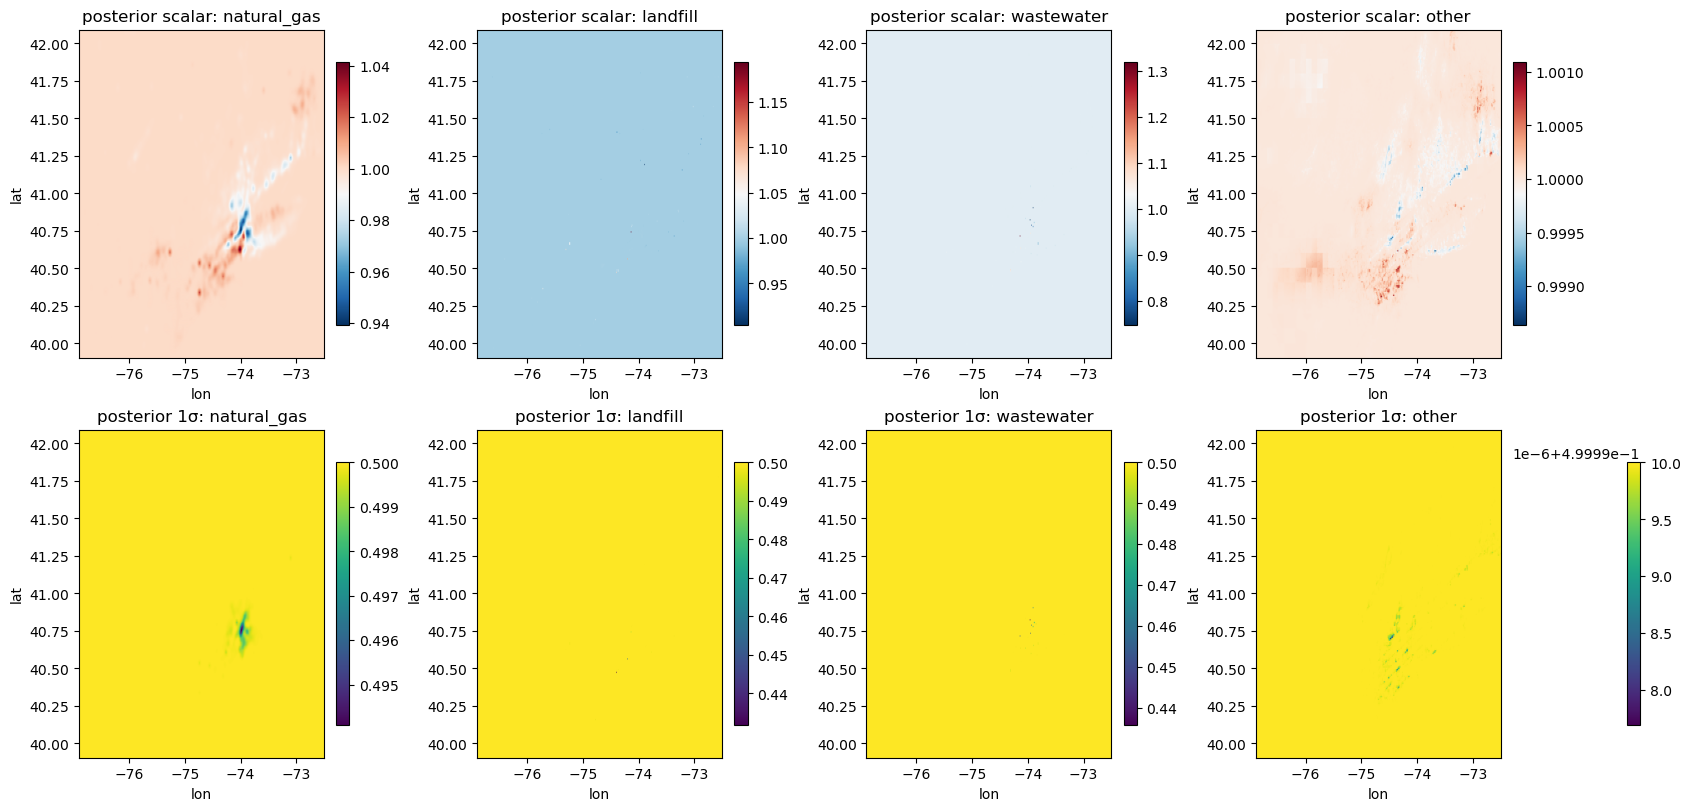

In [7]:
grid, core = inv.grid, inv.core
m = core.mask
rows = np.where(m.any(1))[0]; cols = np.where(m.any(0))[0]
r0, r1, c0, c1 = rows[0], rows[-1]+1, cols[0], cols[-1]+1
EXTENT = [grid.lon[c0], grid.lon[c1-1], grid.lat[r0], grid.lat[r1-1]]
crop = lambda f: f[r0:r1, c0:c1]

cats = [b.name for b in inv.state.blocks if b.name not in ('bc', 'buffer')]
std_parts = inv.state.unpack(inv.posterior.stddev())
fig, ax = plt.subplots(2, len(cats), figsize=(4.2*len(cats), 8), constrained_layout=True, squeeze=False)
for j, name in enumerate(cats):
    im0 = ax[0, j].imshow(crop(inv.field(name)), origin='lower', extent=EXTENT, aspect='auto',
                          cmap='RdBu_r')#, vmin=0.5, vmax=1.5)
    ax[0, j].set_title(f'posterior scalar: {name}'); fig.colorbar(im0, ax=ax[0, j], shrink=0.8)
    ustd = core.to_field(std_parts[name])
    im1 = ax[1, j].imshow(crop(ustd), origin='lower', extent=EXTENT, aspect='auto', cmap='viridis')
    ax[1, j].set_title(f'posterior 1\u03c3: {name}'); fig.colorbar(im1, ax=ax[1, j], shrink=0.8)
for a in ax.ravel(): a.set_xlabel('lon'); a.set_ylabel('lat')
plt.show()

## 3. Observation diagnostics

The bundle stores the per-receptor observation context: observed XCH4, fitted background, enhancement (`z = obs - bg`), modeled value (`Hx̂`, NaN for dropped outliers), flight index, and outlier flag. Residual = enhancement − modeled.

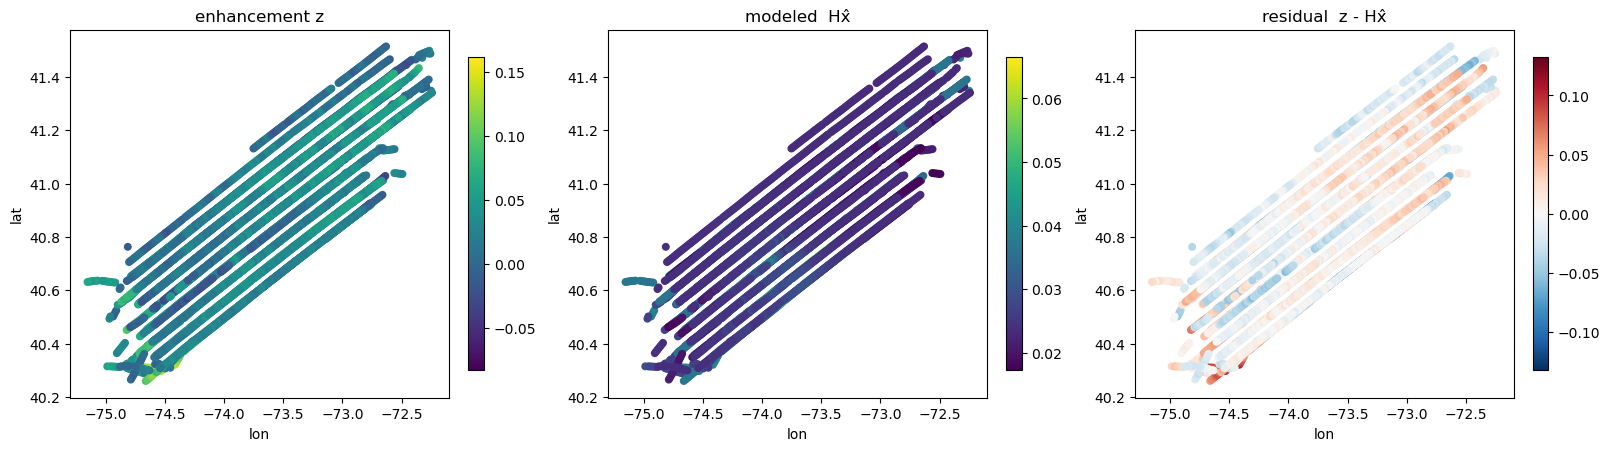

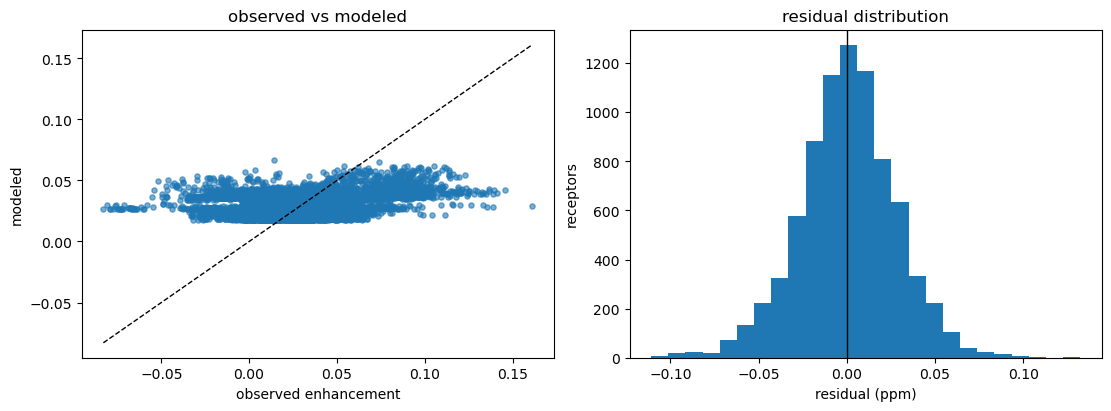

In [8]:
R = inv.receptors
rlat, rlon = R['receptor_lat'], R['receptor_lon']
z, modeled = R['enhancement'], R['modeled']
resid = z - modeled
flag = R.get('outlier_flag', np.zeros_like(rlat)).astype(bool)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)
for a, (title, val, cmap) in zip(ax, [('enhancement z', z, 'viridis'),
        ('modeled  Hx\u0302', modeled, 'viridis'), ('residual  z - Hx\u0302', resid, 'RdBu_r')]):
    vlim = np.nanmax(np.abs(resid)) if cmap == 'RdBu_r' else None
    kw = dict(vmin=-vlim, vmax=vlim) if vlim else {}
    s = a.scatter(rlon, rlat, c=val, s=22, cmap=cmap, **kw)
    if flag.any():
        a.scatter(rlon[flag], rlat[flag], s=80, facecolors='none', edgecolors='k', label='outlier')
        a.legend(loc='upper left')
    a.set_title(title); a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(s, ax=a, shrink=0.85)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
ax[0].scatter(z, modeled, s=14, alpha=0.6); lim = [np.nanmin(z), np.nanmax(z)]
ax[0].plot(lim, lim, 'k--', lw=1); ax[0].set_xlabel('observed enhancement'); ax[0].set_ylabel('modeled')
ax[0].set_title('observed vs modeled')
ax[1].hist(resid[np.isfinite(resid)], bins=25); ax[1].axvline(0, color='k', lw=1)
ax[1].set_xlabel('residual (ppm)'); ax[1].set_ylabel('receptors'); ax[1].set_title('residual distribution')
plt.show()

## 4. Model–data mismatch

Beyond the raw residual map, the saved observation context lets us check whether the assumed error model is consistent with the fit. We look at the **normalized residuals**, per-flight **bias/RMS**, and the **along-track autocorrelation** of the residual — the latter is the signature of correlated model–data mismatch (overlapping column footprints), which is exactly what the components error model in `obs_error.py` represents.

reduced chi-square (saved): 0.388   (~1 = error model consistent)
residual: mean +0.0003  rms 0.0277 ppm  robust sigma(MAD) 0.0248 ppm
  flight 20230726_1     n=1271  bias +0.0004  rms 0.0347 ppm
  flight 20230726_2     n=1203  bias +0.0000  rms 0.0187 ppm
  flight 20230728_1     n=1138  bias +0.0013  rms 0.0334 ppm
  flight 20230728_2     n=1347  bias -0.0004  rms 0.0360 ppm
  flight 20230805       n=1530  bias +0.0004  rms 0.0189 ppm
  flight 20230809       n=1589  bias +0.0000  rms 0.0208 ppm


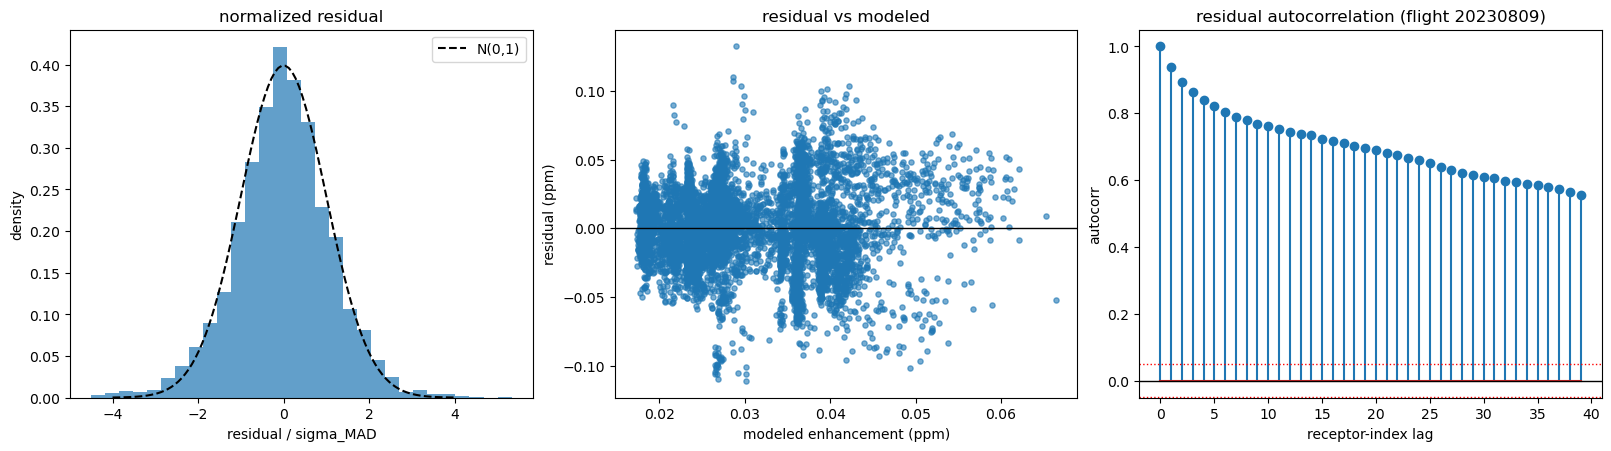

In [9]:
R = inv.receptors
z, modeled = R['enhancement'], R['modeled']
resid = z - modeled
flag = R.get('outlier_flag', np.zeros_like(z)).astype(bool)
flight = R.get('receptor_flight', np.zeros_like(z, dtype=int)).astype(int)
fin = np.isfinite(resid) & ~flag

# robust mismatch scale (MAD) and normalized residuals
med = np.median(resid[fin])
sigma_mad = 1.4826 * np.median(np.abs(resid[fin] - med))
nresid = (resid - med) / sigma_mad

chi2r = inv.diagnostics.get('reduced_chi_square', float('nan'))
print(f'reduced chi-square (saved): {chi2r:.3f}   (~1 = error model consistent)')
print(f'residual: mean {np.mean(resid[fin]):+.4f}  rms {np.sqrt(np.mean(resid[fin]**2)):.4f} ppm  '
      f'robust sigma(MAD) {sigma_mad:.4f} ppm')
for f in np.unique(flight):
    sel = fin & (flight == f)
    fid = inv.flight_ids[f] if f < len(inv.flight_ids) else str(f)
    print(f'  flight {fid:<14} n={sel.sum():4d}  bias {np.mean(resid[sel]):+.4f}  '
          f'rms {np.sqrt(np.mean(resid[sel]**2)):.4f} ppm')

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)
# (a) normalized-residual histogram vs N(0,1)
ax[0].hist(nresid[fin], bins=30, density=True, alpha=0.7)
xx = np.linspace(-4, 4, 100)
ax[0].plot(xx, np.exp(-xx**2 / 2) / np.sqrt(2 * np.pi), 'k--', label='N(0,1)')
ax[0].set_xlabel('residual / sigma_MAD'); ax[0].set_ylabel('density')
ax[0].set_title('normalized residual'); ax[0].legend()
# (b) residual vs modeled (bias / heteroscedasticity)
ax[1].scatter(modeled[fin], resid[fin], s=14, alpha=0.6); ax[1].axhline(0, color='k', lw=1)
ax[1].set_xlabel('modeled enhancement (ppm)'); ax[1].set_ylabel('residual (ppm)')
ax[1].set_title('residual vs modeled')
# (c) along-track autocorrelation, computed within the largest flight (index order ~ track)
big = np.bincount(flight[fin]).argmax()
r = resid[fin & (flight == big)]
r = (r - r.mean()) / (r.std() + 1e-12)
maxlag = min(40, max(2, r.size - 1))
ac = np.array([1.0 if k == 0 else float(np.mean(r[:-k] * r[k:])) for k in range(maxlag)])
ax[2].stem(range(maxlag), ac)
ax[2].axhline(0, color='k', lw=1)
for h in (1, -1):
    ax[2].axhline(h * 1.96 / np.sqrt(r.size), color='r', ls=':', lw=1)
ax[2].set_xlabel('receptor-index lag'); ax[2].set_ylabel('autocorr')
ax[2].set_title(f'residual autocorrelation (flight {inv.flight_ids[big] if big < len(inv.flight_ids) else big})')
plt.show()

## 5. Retrieved background offset(s)

One optimized offset per flight, on top of the fitted background plane.

In [10]:
if 'bc' in inv.state.names:
    bc = inv.block('bc'); bc_sd = inv.state.unpack(inv.posterior.stddev())['bc']
    for fid, v, s in zip(inv.flight_ids, bc, bc_sd):
        print(f'  background offset [{fid}]: {v:+.4f} +/- {s:.4f} ppm')
else:
    print('no background-offset block in this inversion')

  background offset [20230726_1]: +0.0379 +/- 0.0016 ppm
  background offset [20230726_2]: +0.0211 +/- 0.0016 ppm
  background offset [20230728_1]: +0.0259 +/- 0.0016 ppm
  background offset [20230728_2]: +0.0339 +/- 0.0015 ppm
  background offset [20230805]: +0.0170 +/- 0.0016 ppm
  background offset [20230809]: +0.0229 +/- 0.0014 ppm


## 6. Buffer region (out-of-core nuisance state)

If the inversion enabled a coarse buffer, the bundle stores its super-cell geometry (`inv.buffer`) and the buffer block lives in the state vector. The buffer absorbs out-of-core emissions so they do not alias into the core edge; it is reported here for inspection but is **not** part of the core total. We compare each super-cell's **prior** flux (area-weighted inventory density) with its **posterior** ± 1σ, and map both.

buffer: 3258 super-cells over 308580 native cells (mode in config; geometry from the bundle)


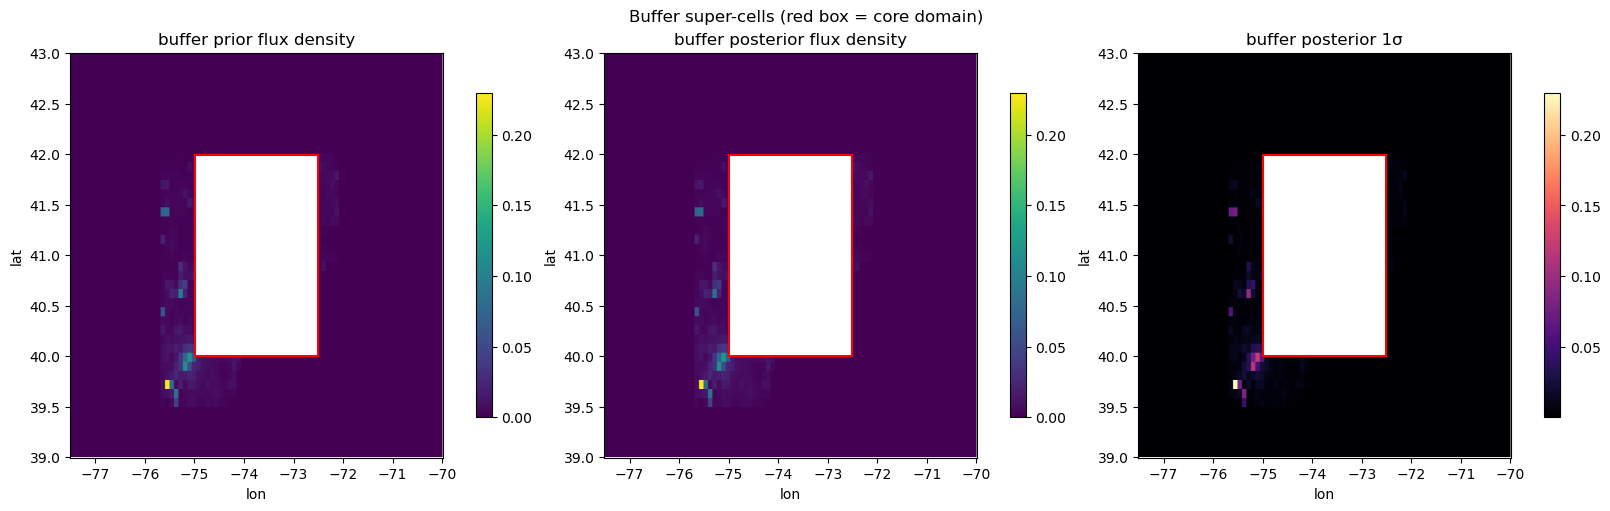

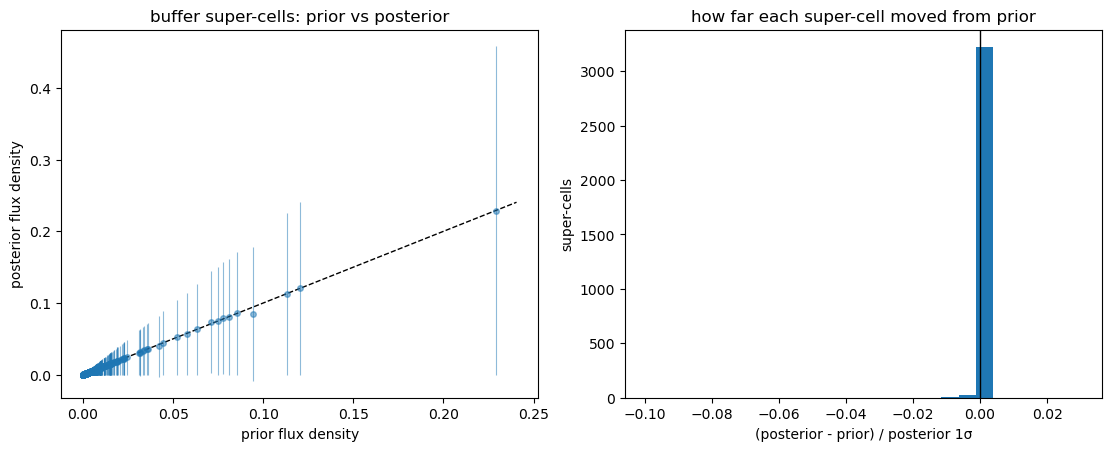

In [8]:
buf = inv.buffer
if buf is None or 'buffer' not in inv.state.names:
    print('no buffer region in this inversion (enable [buffer] in the config to use one)')
else:
    memb = np.asarray(buf['membership'])                       # (n_lat, n_lon), -1 off-buffer
    prior_b = inv.state.unpack(inv.xa)['buffer']               # prior mean per super-cell
    post_b = inv.block('buffer')                               # posterior mean
    post_sd = inv.state.unpack(inv.posterior.stddev())['buffer']
    n_super = post_b.size
    print(f'buffer: {n_super} super-cells over {(memb >= 0).sum()} native cells '
          f'(mode in config; geometry from the bundle)')

    grid, core = inv.grid, inv.core

    def to_grid(vals):
        f = np.full(memb.shape, np.nan)
        ok = memb >= 0
        f[ok] = np.asarray(vals)[memb[ok]]
        return f

    # window covering core + buffer
    reg = (memb >= 0) | core.mask
    ii, jj = np.where(reg)
    pad = 1
    i0, i1 = max(ii.min() - pad, 0), min(ii.max() + pad + 1, grid.n_lat)
    j0, j1 = max(jj.min() - pad, 0), min(jj.max() + pad + 1, grid.n_lon)
    ext = [grid.lon[j0], grid.lon[j1 - 1], grid.lat[i0], grid.lat[i1 - 1]]
    cropb = lambda f: f[i0:i1, j0:j1]
    # core extent (for an outline box)
    clat, clon = core.active_lat, core.active_lon
    core_box = Rectangle((clon.min(), clat.min()), clon.max() - clon.min(),
                         clat.max() - clat.min(), fill=False, ec='red', lw=1.5)

    fig, ax = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    vmax = np.nanmax([np.nanmax(to_grid(prior_b)), np.nanmax(to_grid(post_b))])
    for a, (title, fld, cmap, vlim) in zip(ax, [
            ('buffer prior flux density', to_grid(prior_b), 'viridis', (0, vmax)),
            ('buffer posterior flux density', to_grid(post_b), 'viridis', (0, vmax)),
            ('buffer posterior 1σ', to_grid(post_sd), 'magma', (None, None))]):
        kw = {} if vlim[0] is None else dict(vmin=vlim[0], vmax=vlim[1])
        im = a.imshow(cropb(fld), origin='lower', extent=ext, aspect='auto', cmap=cmap, **kw)
        a.add_patch(Rectangle((clon.min(), clat.min()), clon.max() - clon.min(),
                              clat.max() - clat.min(), fill=False, ec='red', lw=1.5))
        a.set_title(title); a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(im, ax=a, shrink=0.8)
    plt.suptitle('Buffer super-cells (red box = core domain)'); plt.show()

    # prior vs posterior per super-cell (update direction + uncertainty)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
    ax[0].errorbar(prior_b, post_b, yerr=post_sd, fmt='o', ms=4, alpha=0.5, lw=0.8)
    lim = [0, float(np.nanmax([prior_b.max(), post_b.max()])) * 1.05 + 1e-12]
    ax[0].plot(lim, lim, 'k--', lw=1)
    ax[0].set_xlabel('prior flux density'); ax[0].set_ylabel('posterior flux density')
    ax[0].set_title('buffer super-cells: prior vs posterior')
    upd = np.where(post_sd > 0, (post_b - prior_b) / post_sd, 0.0)
    ax[1].hist(upd, bins=25)
    ax[1].axvline(0, color='k', lw=1)
    ax[1].set_xlabel('(posterior - prior) / posterior 1σ'); ax[1].set_ylabel('super-cells')
    ax[1].set_title('how far each super-cell moved from prior')
    plt.show()

## 7. Post-hoc re-aggregation with uncertainty

This is the payoff: define **any** linear functional of the state and get its posterior mean and uncertainty via `inv.estimate(A)` — exact, no operator. The integrated flux of a region is `Σ_cells scalar × prior × area` over that region, which is linear in the state. Below: the domain total, a tiled regional breakdown, and the sector totals with their cross-covariance.

The buffer block is a nuisance state and is **excluded** from these core totals (the `gridded` list below drops both `bc` and `buffer`).

In [9]:
areas = core.from_field(cell_areas_m2(grid))                 # m^2 per active cell
gridded = [b.name for b in inv.state.blocks if b.name not in ('bc', 'buffer')]

def block_prior(name):
    """Prior emission on active cells for a state block (category field or total)."""
    if name in inv.group_fields:
        return inv.group_fields[name]
    return sum(inv.group_fields.values())                    # single-inventory 'total' block

def flux_functional(cell_weight=None, blocks=None):
    """Aggregation vector a so that aᵀx = integrated flux over the (weighted) region."""
    a = np.zeros(inv.state.size)
    for name in (blocks or gridded):
        w = block_prior(name) * areas
        if cell_weight is not None:
            w = w * cell_weight
        a[inv.state.slice(name)] = w
    return a

# domain total +/- 1 sigma
(tot,), totcov = inv.estimate(flux_functional()[None, :])
print(f'domain total flux: {tot:.4e} +/- {totcov[0,0]**0.5:.3e}  ({inv.report["unit_label"]})')

domain total flux: 5.9094e+08 +/- 1.069e+07  (prior-units x m^2 (native))


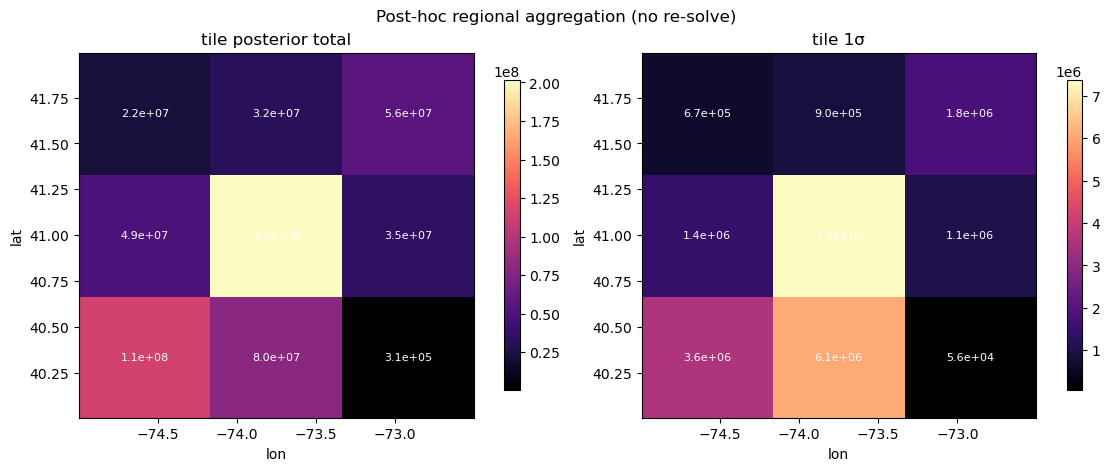

tiles sum to 5.9094e+08 vs domain total 5.9094e+08


In [10]:
# regional sub-totals: split the active domain into an NxN grid of tiles and
# aggregate each (with uncertainty) post-hoc
N = 3
alat, alon = core.active_lat, core.active_lon
lat_edges = np.linspace(alat.min(), alat.max()+1e-9, N+1)
lon_edges = np.linspace(alon.min(), alon.max()+1e-9, N+1)
rowsA = []
for i in range(N):
    for j in range(N):
        w = ((alat >= lat_edges[i]) & (alat < lat_edges[i+1]) &
             (alon >= lon_edges[j]) & (alon < lon_edges[j+1])).astype(float)
        rowsA.append(flux_functional(cell_weight=w))
means, cov = inv.estimate(np.array(rowsA))
tile_tot = means.reshape(N, N); tile_sd = np.sqrt(np.clip(np.diag(cov), 0, None)).reshape(N, N)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
ext = [lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]]
for a, (title, fld) in zip(ax, [('tile posterior total', tile_tot), ('tile 1\u03c3', tile_sd)]):
    im = a.imshow(fld, origin='lower', extent=ext, aspect='auto', cmap='magma')
    for i in range(N):
        for j in range(N):
            a.text((lon_edges[j]+lon_edges[j+1])/2, (lat_edges[i]+lat_edges[i+1])/2,
                   f'{fld[i,j]:.1e}', ha='center', va='center', color='w', fontsize=8)
    a.set_title(title); a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(im, ax=a, shrink=0.85)
plt.suptitle('Post-hoc regional aggregation (no re-solve)'); plt.show()
print(f'tiles sum to {tile_tot.sum():.4e} vs domain total {tot:.4e}')

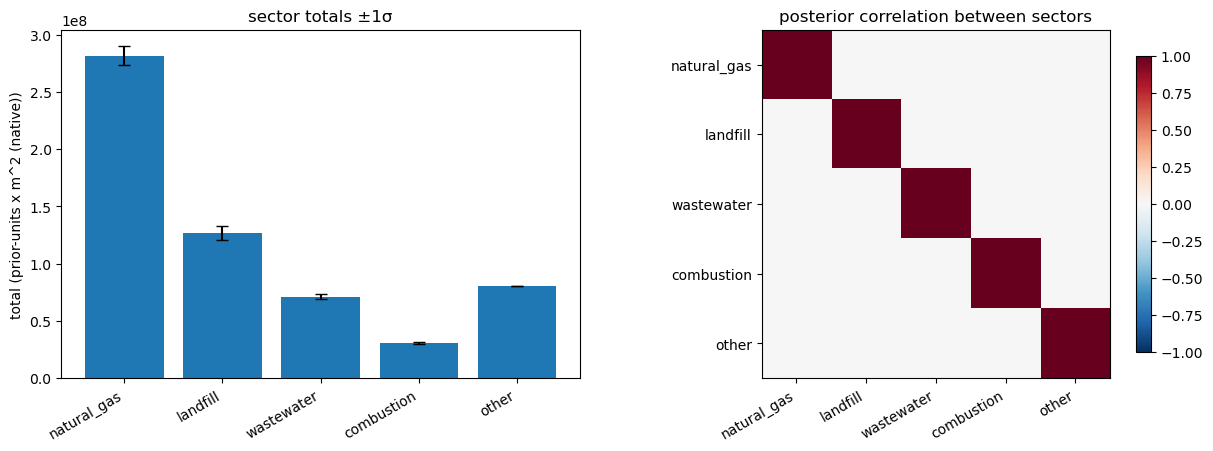

sector totals sum to 5.9094e+08 vs domain total 5.9094e+08


In [11]:
# sector totals + cross-covariance: aggregate each category block separately, so
# estimate() returns the full inter-sector covariance (not just per-sector sigma)
if len(gridded) > 1:
    A = np.array([flux_functional(blocks=[name]) for name in gridded])
    smeans, scov = inv.estimate(A)
    ssd = np.sqrt(np.clip(np.diag(scov), 0, None))
    corr = scov / np.outer(ssd, ssd)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
    x = np.arange(len(gridded))
    ax[0].bar(x, smeans, yerr=ssd, capsize=4)
    ax[0].set_xticks(x); ax[0].set_xticklabels(gridded, rotation=30, ha='right')
    ax[0].set_ylabel(f'total ({inv.report["unit_label"]})'); ax[0].set_title('sector totals \u00b11\u03c3')
    im = ax[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax[1].set_xticks(x); ax[1].set_xticklabels(gridded, rotation=30, ha='right')
    ax[1].set_yticks(x); ax[1].set_yticklabels(gridded)
    ax[1].set_title('posterior correlation between sectors'); fig.colorbar(im, ax=ax[1], shrink=0.85)
    plt.show()
    print('sector totals sum to', f'{smeans.sum():.4e}', 'vs domain total', f'{tot:.4e}')
else:
    print('single gridded block (total mode): sectors are obtained by post-hoc')
    print('variance partition - see halo_oe.decomposition.partition_by_prior_variance')

## Takeaways

Everything above came from the reloaded bundle alone — **no Jacobian, no re-solve**:

- `inv.field(name)` / `inv.block(name)` — posterior fields and block values; `posterior.stddev()` for uncertainty.
- `inv.receptors` — the full observation context (obs, background, enhancement, modeled, flight, outlier flag) for residual and QC analysis.
- `inv.estimate(A)` — the engine for post-hoc work: any linear functional's posterior **mean and full covariance**. Build `A` for a region (tiled), a sector (per category block), or any custom aggregation/disaggregation, and you get the answer with correct uncertainty, including cross-terms.
- `inv.group_fields` — the super-category prior fields, for re-grouping categories or a variance-weighted disaggregation.

Run the expensive inversion once with `--save`; explore the posterior as many ways as you like from the bundle.

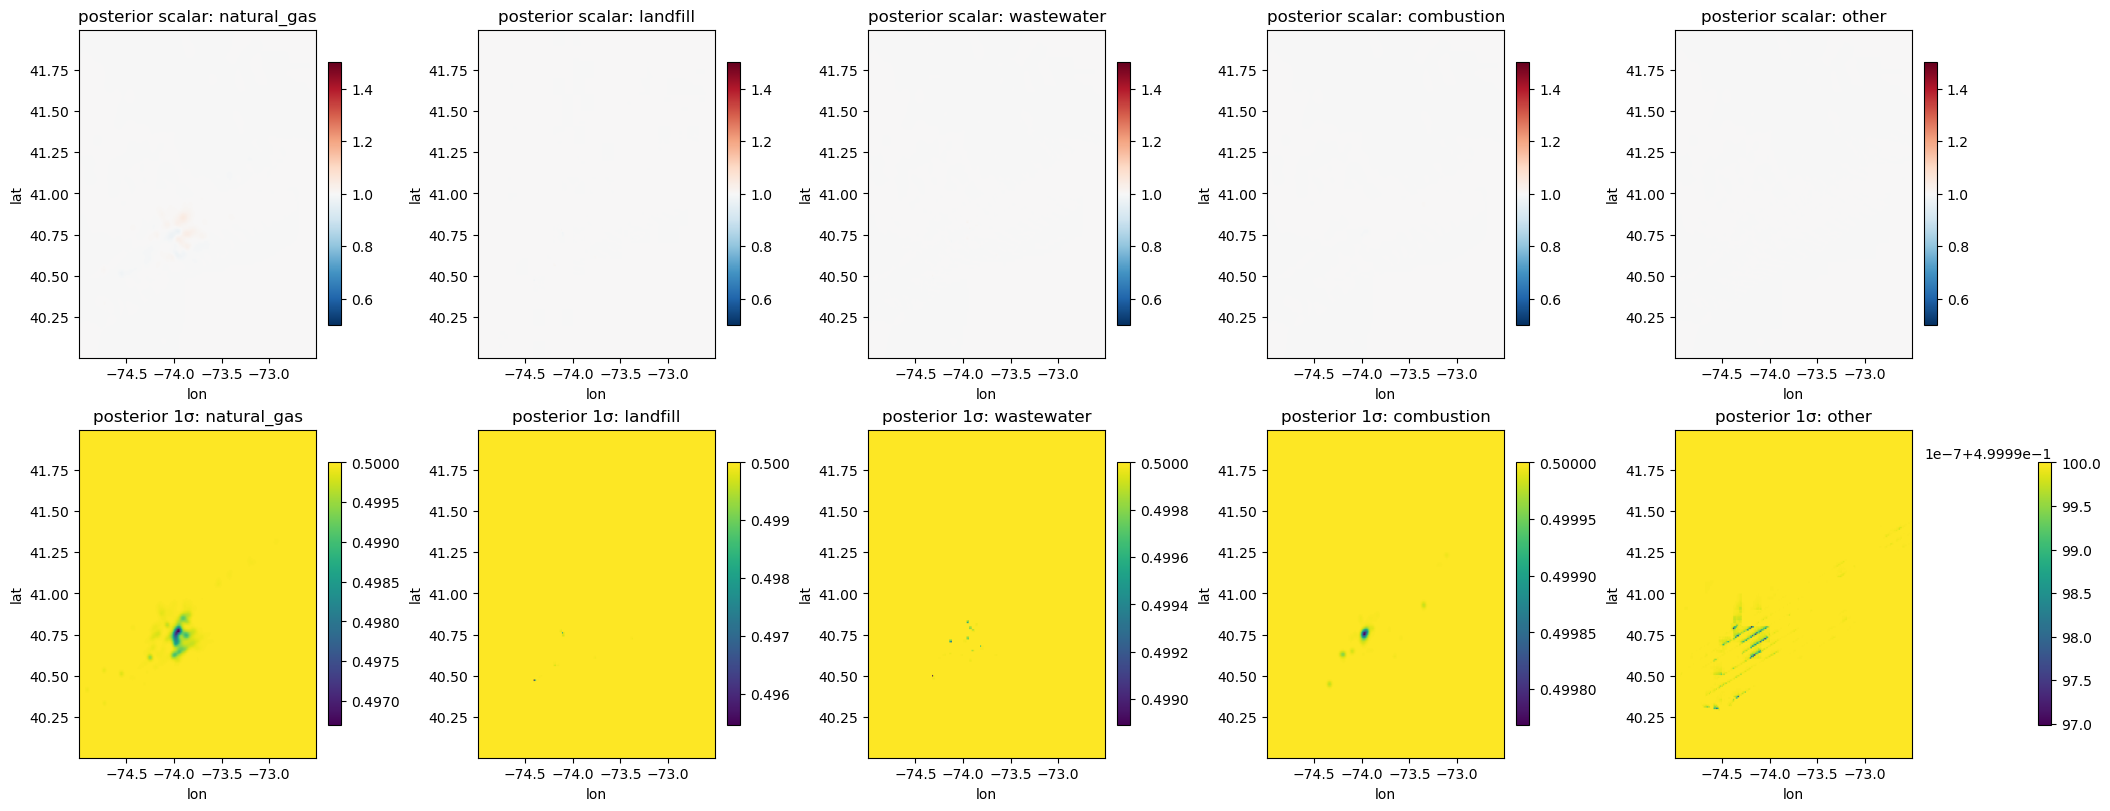

In [1]:
import os, sys, tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

BAYES_OPT = os.path.dirname(os.path.dirname(os.path.abspath('saved_bundle_analysis.ipynb')))
if BAYES_OPT not in sys.path:
    sys.path.insert(0, BAYES_OPT)
import halo_oe  # noqa: F401

from halo_oe.io_bundle import load_inversion
from halo_oe.flux import cell_areas_m2

# Set this to a real bundle directory (from `run_halo.py --save`) to analyze real
# results. Bundles now live under bayes_opt/runs/. If the path does not exist, a
# small synthetic bundle (with a buffer region) is built below.
BUNDLE_DIR = os.environ.get('HALO_BUNDLE', os.path.join(BAYES_OPT, 'runs', 'bg_deg2'))

from halo_oe.plotting import plot_posterior
BUNDLE_DIR = os.environ.get('HALO_BUNDLE', os.path.join(BAYES_OPT, 'runs', 'bg_deg2'))
plot_posterior(load_inversion(BUNDLE_DIR), out_path=None)